In [6]:
import ehrapy as ep
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from tableone import TableOne

import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from fairlearn.metrics import MetricFrame, false_negative_rate, selection_rate
from fairlearn.postprocessing import ThresholdOptimizer

In [23]:
from fairlearn.datasets import fetch_diabetes_hospital

data = fetch_diabetes_hospital()
X = data.data
y = data.target
data

{'data':                    race  gender                    age  \
 0             Caucasian  Female  '30 years or younger'   
 1             Caucasian  Female  '30 years or younger'   
 2       AfricanAmerican  Female  '30 years or younger'   
 3             Caucasian    Male          '30-60 years'   
 4             Caucasian    Male          '30-60 years'   
 ...                 ...     ...                    ...   
 101761  AfricanAmerican    Male        'Over 60 years'   
 101762  AfricanAmerican  Female        'Over 60 years'   
 101763        Caucasian    Male        'Over 60 years'   
 101764        Caucasian  Female        'Over 60 years'   
 101765        Caucasian    Male        'Over 60 years'   
 
        discharge_disposition_id admission_source_id  time_in_hospital  \
 0                         Other            Referral                 1   
 1          'Discharged to Home'           Emergency                 3   
 2          'Discharged to Home'           Emergency        

In [43]:
import anndata as ad
import pandas as pd
from fairlearn.datasets import fetch_diabetes_hospital

data = fetch_diabetes_hospital(as_frame=True)
df = data.data.copy()
df["readmitted"] = data.target  # add target back

obs_cols = ["race", "gender", "age", "readmitted", "readmit_binary", "discharge_disposition_id"]
X_cols = [c for c in df.columns if c not in obs_cols]

adata_algo = ad.AnnData(X=df[X_cols].values, obs=df[obs_cols])
adata_algo.var_names = X_cols




# adata_algo.obs["readmit_30_days"] = adata_algo.obs["readmitted"] == "<30"
adata_algo.obs["readmit_30_days"] = adata_algo.obs["readmit_binary"] == 1


# print(adata_algo.obs[["readmitted", "readmit_30_days"]])
print(adata_algo.obs["readmitted"].unique())
print(adata_algo.obs["readmit_30_days"].value_counts())  # tr
adata_algo

[0 1]
readmit_30_days
False    54864
True     46902
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 101766 × 18
    obs: 'race', 'gender', 'age', 'readmitted', 'readmit_binary', 'discharge_disposition_id', 'readmit_30_days'

In [44]:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [45]:
TableOne(adata_algo.obs, columns=["race", "gender", "age"])

Missing       Overall
n                                                  101766
race, n (%)   AfricanAmerican                19210 (18.9)
              Asian                             641 (0.6)
              Caucasian                      76099 (74.8)
              Hispanic                         2037 (2.0)
              Other                            1506 (1.5)
              Unknown                          2273 (2.2)
gender, n (%) Female                         54708 (53.8)
              Male                           47055 (46.2)
              Unknown/Invalid                     3 (0.0)
age, n (%)    '30 years or younger'            2509 (2.5)
              '30-60 years'                  30716 (30.2)
              'Over 60 years'                68541 (67.4)

In [46]:
# aggregate small groups
adata_algo.obs["race_all"] = adata_algo.obs["race"]
adata_algo.obs["race"] = adata_algo.obs["race"].replace(
    {"Asian": "Other", "Hispanic": "Other"}
)

# drop gender group Unknown/Invalid
adata_algo = adata_algo[adata_algo.obs["gender"] != "Unknown/Invalid", :].copy()
ep.ad.move_to_x(adata_algo, "gender")

AnnData object with n_obs × n_vars = 101763 × 19
    obs: 'race', 'age', 'readmitted', 'readmit_binary', 'discharge_disposition_id', 'readmit_30_days', 'race_all'

In [47]:
# encode categorical data to one-hot
adata_algo = ep.pp.encode(
    adata_algo,
    autodetect=True,
)

! Features 'time_in_hospital', 'num_procedures', 'number_diagnoses' were detected as categorical features stored numerically.Please verify and correct using `ep.ad.replace_feature_types` if necessary.
! Feature types were inferred and stored in adata.var[feature_type]. Please verify using `ep.ad.feature_type_overview` and adjust if necessary using `ep.ad.replace_feature_types`.


In [48]:
# train-test 50-50 split
train_idxs, test_idxs = train_test_split(
    np.arange(adata_algo.n_obs),
    stratify=adata_algo.obs["race"],
    test_size=0.5,
    random_state=40,
)
adata_algo_train = adata_algo[train_idxs, :]
adata_algo_test = adata_algo[test_idxs, :]

In [49]:
adata_algo_train
adata_algo_test

View of AnnData object with n_obs × n_vars = 50882 × 45
    obs: 'race', 'gender', 'age', 'readmitted', 'readmit_binary', 'discharge_disposition_id', 'readmit_30_days', 'race_all', 'admission_source_id', 'medical_specialty', 'primary_diagnosis', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed', 'medicare', 'medicaid', 'had_emergency', 'had_inpatient_days', 'had_outpatient_days'
    var: 'feature_type', 'unencoded_var_names', 'encoding_mode'
    layers: 'original'

In [50]:
print(adata_algo.obs["readmitted"].unique())
print(adata_algo.obs["readmit_30_days"].unique())
print(adata_algo.obs["readmit_30_days"].value_counts())

[0 1]
[False  True]
readmit_30_days
False    54861
True     46902
Name: count, dtype: int64


In [51]:
# train set balanced for readmit_30_days label
adata_algo_train_balanced = ep.pp.balanced_sample(
    adata_algo_train,
    key="readmit_30_days",
    method="RandomUnderSampler",
    random_state=0,
    copy=True,
)
adata_algo_train_balanced.obs["readmit_30_days"].value_counts()

readmit_30_days
False    23448
True     23448
Name: count, dtype: int64

In [52]:
unmitigated_pipeline = Pipeline(
    steps=[
        ("preprocessing", StandardScaler()),
        ("logistic_regression", LogisticRegression(max_iter=1000)),
    ]
)

In [53]:
unmitigated_pipeline.fit(
    adata_algo_train_balanced.X,
    adata_algo_train_balanced.obs["readmit_30_days"].astype(bool),
)

,steps,"[('preprocessing', ...), ('logistic_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


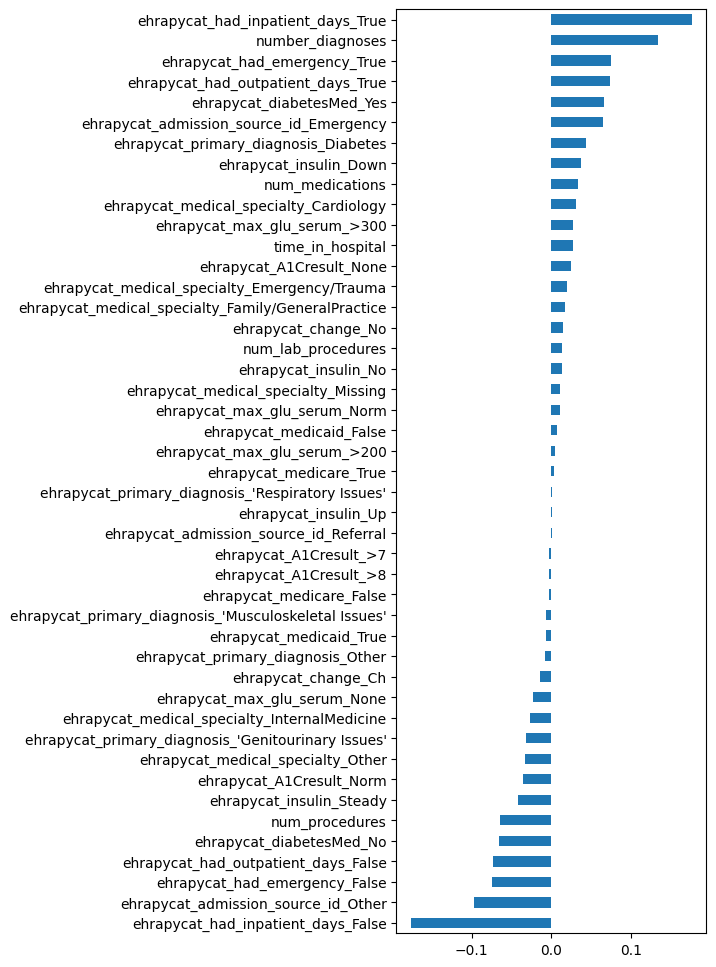

In [54]:
coef_series = pd.Series(
    data=unmitigated_pipeline.named_steps["logistic_regression"].coef_[0],
    index=adata_algo_train_balanced.var_names,
)
coef_series.sort_values().plot.barh(figsize=(4, 12), legend=False);

In [55]:

Y_pred_proba = unmitigated_pipeline.predict_proba(adata_algo_test.X)[:, 1]
Y_pred = unmitigated_pipeline.predict(adata_algo_test.X)

In [56]:
balanced_accuracy_score(
    adata_algo_test.obs["readmit_30_days"].astype(bool), Y_pred.astype(bool)
)

In [57]:
metrics_dict = {
    "selection_rate": selection_rate,
    "false_negative_rate": false_negative_rate,
    "balanced_accuracy": balanced_accuracy_score,
}

mf1 = MetricFrame(
    metrics=metrics_dict,
    y_true=adata_algo_test.obs["readmit_30_days"],
    y_pred=Y_pred,
    sensitive_features=adata_algo_test.obs["race"],
)

mf1.by_group

,selection_rate,false_negative_rate,balanced_accuracy
race,,,
AfricanAmerican,0.428110,0.446722,0.616360
Caucasian,0.435821,0.446470,0.610452
Other,0.371893,0.487776,0.619048
Unknown,0.240529,0.614173,0.609359


In [58]:
df_long = pd.melt(
    mf1.by_group.reset_index(), id_vars=["race"], var_name="metric", value_name="value"
)

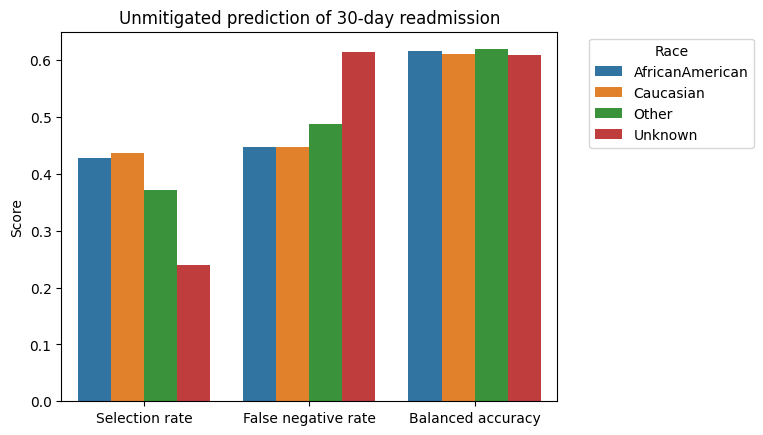

In [61]:
# palette = [colors[0], colors[2], colors[3], colors[5]]
palette = sns.color_palette("tab10")


fig, ax = plt.subplots()
bar = sns.barplot(data=df_long, x="metric", y="value", hue="race", palette=palette)
ax.legend(title="Race", bbox_to_anchor=(1.05, 1))
ax.set_ylabel("Score")
ax.set_xlabel(None)
ax.set_title("Unmitigated prediction of 30-day readmission")
ax.set_xticklabels(
    labels=["Selection rate", "False negative rate", "Balanced accuracy"]
)

plt.savefig("algorithmic_bias_1.pdf", dpi=300, bbox_inches="tight")

In [62]:
postprocess_est = ThresholdOptimizer(
    estimator=unmitigated_pipeline,
    constraints="false_negative_rate_parity",
    objective="balanced_accuracy_score",
    prefit=True,
    predict_method="predict_proba",
)
postprocess_est.fit(
    adata_algo_train_balanced.X,
    adata_algo_train_balanced.obs["readmit_30_days"],
    sensitive_features=adata_algo_train_balanced.obs["race"],
)
Y_pred_postprocess = postprocess_est.predict(
    adata_algo_test.X, sensitive_features=adata_algo_test.obs["race"]
)
metricframe_postprocess = MetricFrame(
    metrics=metrics_dict,
    y_true=adata_algo_test.obs["readmit_30_days"],
    y_pred=Y_pred_postprocess,
    sensitive_features=adata_algo_test.obs["race"],
)
pd.concat(
    [mf1.by_group, metricframe_postprocess.by_group],
    keys=["Unmitigated", "ThresholdOptimizer"],
    axis=1,
)

Unmitigated                                        \
                selection_rate false_negative_rate balanced_accuracy   
race                                                                   
AfricanAmerican       0.428110            0.446722          0.616360   
Caucasian             0.435821            0.446470          0.610452   
Other                 0.371893            0.487776          0.619048   
Unknown               0.240529            0.614173          0.609359   

                ThresholdOptimizer                                        
                    selection_rate false_negative_rate balanced_accuracy  
race                                                                      
AfricanAmerican           0.440916            0.435008          0.615345  
Caucasian                 0.449093            0.432743          0.610879  
Other                     0.403920            0.444703          0.628419  
Unknown                   0.421145            0.443570          0.601823

In [63]:

Y_pred_mitig = postprocess_est.predict(
    adata_algo_test.X, sensitive_features=adata_algo_test.obs["race"]
)
balanced_accuracy_score(
    adata_algo_test.obs["readmit_30_days"].astype(bool), Y_pred_mitig.astype(bool)
)

In [65]:
df_long_postprocess = pd.melt(
    metricframe_postprocess.by_group.reset_index(),
    id_vars=["race"],
    var_name="metric",
    value_name="value",
)
df_long_postprocess

,race,metric,value
0,AfricanAmerican,selection_rate,0.440916
1,Caucasian,selection_rate,0.449093
2,Other,selection_rate,0.403920
3,Unknown,selection_rate,0.421145
4,AfricanAmerican,false_negative_rate,0.435008
5,Caucasian,false_negative_rate,0.432743
6,Other,false_negative_rate,0.444703
7,Unknown,false_negative_rate,0.443570
8,AfricanAmerican,balanced_accuracy,0.615345
9,Caucasian,balanced_accuracy,0.610879


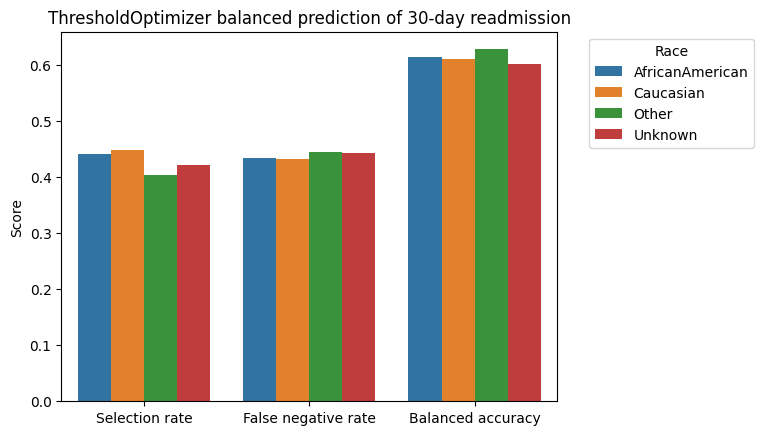

In [66]:
palette = sns.color_palette("tab10")

fig, ax = plt.subplots()
bar = sns.barplot(
    data=df_long_postprocess, x="metric", y="value", hue="race", palette=palette
)

ax.legend(title="Race", bbox_to_anchor=(1.05, 1))
ax.set_ylabel("Score")
ax.set_xlabel(None)
ax.set_xticklabels(
    labels=["Selection rate", "False negative rate", "Balanced accuracy"]
)
ax.set_title("ThresholdOptimizer balanced prediction of 30-day readmission")

max_heights = df_long_postprocess.groupby("metric")["value"].max()

plt.savefig("algorithmic_bias_2.pdf", dpi=300, bbox_inches="tight")